# Restricted Model Fit — Person 0

Fits the soft-margin Model A on the **cleanest subset** of person 0's queries:

- **Remove** any trial with RT > 30s (slow response — likely deliberating, not decisive)
- **Remove** all trials of any query answered inconsistently across sessions (person flipped)

What remains is the set of queries where person 0 was fast **and** always gave the same answer — the most unambiguously decisive responses.

Goal: check whether the best-fit parameters change when we restrict to this high-confidence subset, and whether parameter uncertainty (near-optimal set) tightens.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

df = pd.read_csv('boerstler_data_labeled.csv', index_col=0)

DIFF_COLS = ['alcodiff', 'depdiff', 'lifediff', 'crimdiff']
ATTR      = ['alco', 'dep', 'life', 'crim']
RAW_MAX   = np.array([df[c].abs().max() for c in DIFF_COLS], dtype=float)

P_NOISE = 0.10
A = np.log(2 * (1 - P_NOISE))   # +0.588 per decisive-correct
B = np.log(2 * P_NOISE)          # −1.609 per decisive-error
print(f'p_noise={P_NOISE}  A={A:.3f}  B={B:.3f}  C={-B/A:.2f}')


p_noise=0.1  A=0.588  B=-1.609  C=2.74


In [2]:
# ── Build restricted dataset ─────────────────────────────────────────────────
RT_CUTOFF = 30   # seconds

p0 = df[df['person_id'] == 0].sort_index().copy()
p0['query'] = list(zip(*[p0[c] for c in DIFF_COLS]))

# Filter 1: slow trials (RT > 30s)
slow_mask = p0['secElasped'] > RT_CUTOFF

# Filter 2: inconsistently-answered queries (any query answered both L and R across sessions)
query_choices  = p0.groupby('query')['chosen'].apply(set)
flipped        = set(query_choices[query_choices.map(len) > 1].index)
flipped_mask   = p0['query'].isin(flipped)

# Keep: fast AND consistent
keep = (~slow_mask) & (~flipped_mask)
p0_clean = p0[keep].copy()

print('── Filter summary ────────────────────────────────────────────────')
print(f'Total trials (person 0, all 10 sessions): {len(p0)}')
print(f'  Removed — RT > {RT_CUTOFF}s:                     {slow_mask.sum():>4} trials '
      f'({p0[slow_mask]["query"].nunique()} unique queries)')
print(f'  Removed — inconsistent queries:           {(~slow_mask & flipped_mask).sum():>4} additional trials '
      f'({len(flipped)} queries, {flipped_mask.sum()} trials total, '
      f'{(slow_mask & flipped_mask).sum()} already excluded above)')
print(f'  Kept (fast + consistent):                 {keep.sum():>4} trials '
      f'({p0_clean["query"].nunique()} unique queries)')
print()

# Build c, d, y arrays
c_full  = p0[DIFF_COLS].values / RAW_MAX
d_full  = np.abs(c_full)
y_full  = p0['chosen'].values.astype(int)

c_clean = p0_clean[DIFF_COLS].values / RAW_MAX
d_clean = np.abs(c_clean)
y_clean = p0_clean['chosen'].values.astype(int)

print(f'Full dataset:        n={len(y_full)},  chose_left={y_full.sum()},  chose_right={(1-y_full).sum()}')
print(f'Restricted dataset:  n={len(y_clean)},  chose_left={y_clean.sum()},  chose_right={(1-y_clean).sum()}')

removed = (~keep).values  # boolean mask over 600 full trials


── Filter summary ────────────────────────────────────────────────
Total trials (person 0, all 10 sessions): 600
  Removed — RT > 30s:                       47 trials (42 unique queries)
  Removed — inconsistent queries:             59 additional trials (19 queries, 66 trials total, 7 already excluded above)
  Kept (fast + consistent):                  494 trials (281 unique queries)

Full dataset:        n=600,  chose_left=297,  chose_right=303
Restricted dataset:  n=494,  chose_left=250,  chose_right=244


In [3]:
# ── Helpers (ported from new_model_fitting) ──────────────────────────────────

def simplex_grid(m, k):
    def _gen(rem, dims):
        if dims == 1: yield (rem,); return
        for v in range(rem + 1):
            for rest in _gen(rem - v, dims - 1): yield (v,) + rest
    return np.array(list(_gen(k, m)), dtype=float) / k

def count_dc_de(labels, y):
    dc = int(((labels== 1)&(y==1)).sum() + ((labels==-1)&(y==0)).sum())
    de = int(((labels== 1)&(y==0)).sum() + ((labels==-1)&(y==1)).sum())
    return dc, de

def _wedge_boundaries(tau_r, tau_kappa, x_max=1.05):
    apex_x, apex_y = tau_r / 2, tau_r / 2
    if tau_kappa >= 1.0 - 1e-6:
        return (np.array([apex_x, apex_x]), np.array([apex_y, x_max*5])), \
               (np.array([apex_x, x_max]),  np.array([apex_y, apex_y]))
    m_up = (1 + tau_kappa) / (1 - tau_kappa)
    m_lo = (1 - tau_kappa) / (1 + tau_kappa)
    xs   = np.linspace(apex_x, x_max, 200)
    return (xs, m_up*xs - tau_kappa*tau_r/(1-tau_kappa)), \
           (xs, m_lo*xs + tau_kappa*tau_r/(1+tau_kappa))

OMEGA_GRID = simplex_grid(4, k=10)
TAU_K_VALS = np.arange(0, 1.0, 0.1)
print(f'Grid: {len(OMEGA_GRID)} ω points, {len(TAU_K_VALS)} τ_κ values')


Grid: 286 ω points, 10 τ_κ values


In [4]:
# ── Soft-margin fit on full and restricted datasets ───────────────────────────

def fit_soft(c_mat, d_mat, y, label=''):
    results = []
    cls     = {}
    for omega in OMEGA_GRID:
        r     = d_mat @ omega
        kappa = c_mat @ omega
        for tau_r in np.concatenate([[0.0], np.sort(np.unique(r))]):
            for tau_k in TAU_K_VALS:
                w   = tau_k * np.maximum(0.0, r - tau_r)
                lab = np.zeros(len(y), dtype=np.int8)
                lab[(r >= tau_r) & ( kappa > w)] =  1
                lab[(r >= tau_r) & (-kappa > w)] = -1
                dc, de = count_dc_de(lab, y)
                score  = dc * A + de * B
                results.append(dict(omega=omega.copy(), tau_r=tau_r, tau_kappa=tau_k,
                                    dc=dc, de=de, score=score, labels=lab.copy()))
                key = lab.tobytes()
                if key not in cls:
                    cls[key] = dict(labels=lab.copy(), dc=dc, de=de,
                                    score=score, triples=[])
                cls[key]['triples'].append((omega.copy(), tau_r, tau_k))
    results.sort(key=lambda x: -x['score'])
    print(f'{label}: {len(results)} triples, {len(cls)} equivalence classes')
    return results, cls


t0 = time.time()
print('Fitting full dataset...')
res_full, cls_full = fit_soft(c_full, d_full, y_full, 'Full (600 trials)')

print('Fitting restricted dataset...')
res_rest, cls_rest = fit_soft(c_clean, d_clean, y_clean, f'Restricted ({len(y_clean)} trials)')
print(f'Fitting done in {time.time()-t0:.0f}s')


Fitting full dataset...
Full (600 trials): 66600 triples, 30855 equivalence classes
Fitting restricted dataset...
Restricted (494 trials): 66570 triples, 30660 equivalence classes
Fitting done in 5s


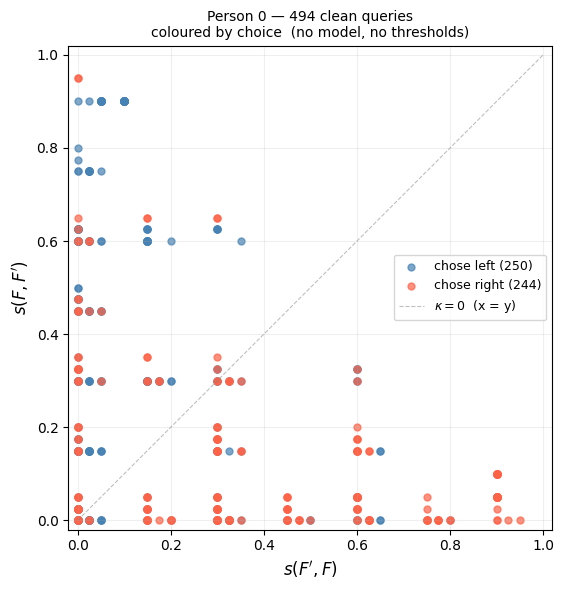

Saved clean_queries_scatter.png


In [5]:
# ── Raw query scatter: 494 clean trials in (sx, sy) space ────────────────────
# sx = s(F',F) = (r - kappa)/2,  sy = s(F,F') = (r + kappa)/2
# Use best-fit omega so axes are on the same scale as wedge plots.

omega_best = res_rest[0]['omega']
r_c     = d_clean @ omega_best
kappa_c = c_clean @ omega_best
sx_c    = (r_c - kappa_c) / 2
sy_c    = (r_c + kappa_c) / 2

left  = y_clean == 1
right = y_clean == 0

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sx_c[left],  sy_c[left],  c='steelblue', s=25, alpha=0.7,
           label=f'chose left ({left.sum()})')
ax.scatter(sx_c[right], sy_c[right], c='tomato',    s=25, alpha=0.7,
           label=f'chose right ({right.sum()})')

ax.plot([0, 1], [0, 1], 'gray', ls='--', lw=0.8, alpha=0.5, label=r'$\kappa = 0$  (x = y)')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.set_xlabel(r"$s(F', F)$", fontsize=12)
ax.set_ylabel(r"$s(F, F')$", fontsize=12)
ax.set_title("Person 0 — 494 clean queries\ncoloured by choice  (no model, no thresholds)", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('clean_queries_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved clean_queries_scatter.png')


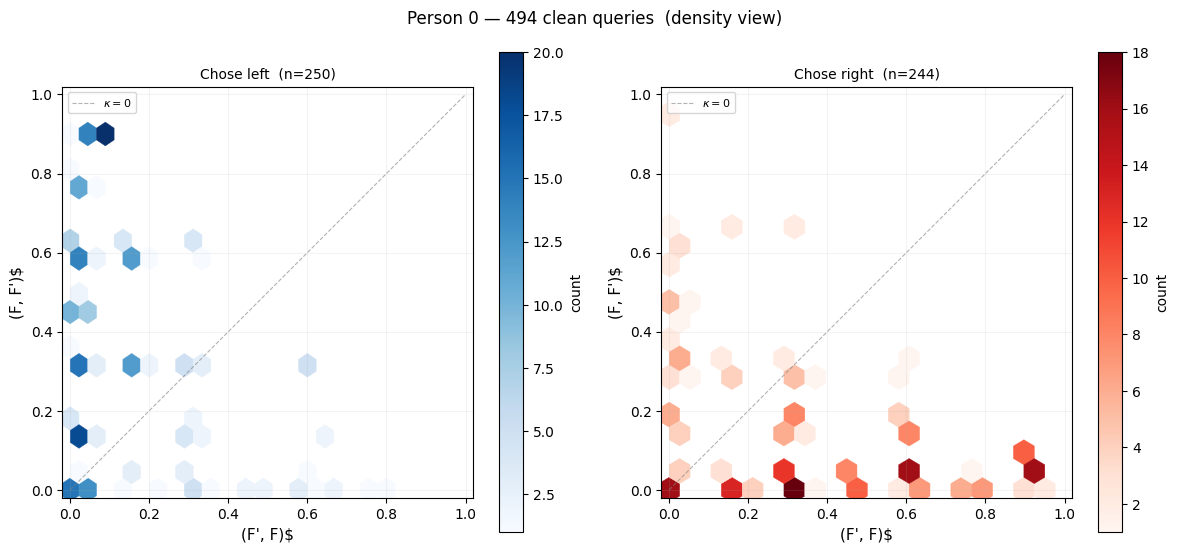

Saved clean_queries_density.png


In [6]:
# ── Density version: hexbin side-by-side ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle("Person 0 — 494 clean queries  (density view)", fontsize=12)

gridsize = 18

for ax, mask, title, cmap in [
    (axes[0], left,  f"Chose left  (n={left.sum()})",  "Blues"),
    (axes[1], right, f"Chose right  (n={right.sum()})", "Reds"),
]:
    hb = ax.hexbin(sx_c[mask], sy_c[mask], gridsize=gridsize,
                   cmap=cmap, mincnt=1, linewidths=0.3)
    plt.colorbar(hb, ax=ax, label="count")
    ax.plot([0, 1], [0, 1], "gray", ls="--", lw=0.8, alpha=0.6, label=r"$\kappa=0$")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    ax.set_xlabel(r"(F', F)$", fontsize=11)
    ax.set_ylabel(r"(F, F')$", fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig("clean_queries_density.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved clean_queries_density.png")


Flipped queries: 19 unique positions


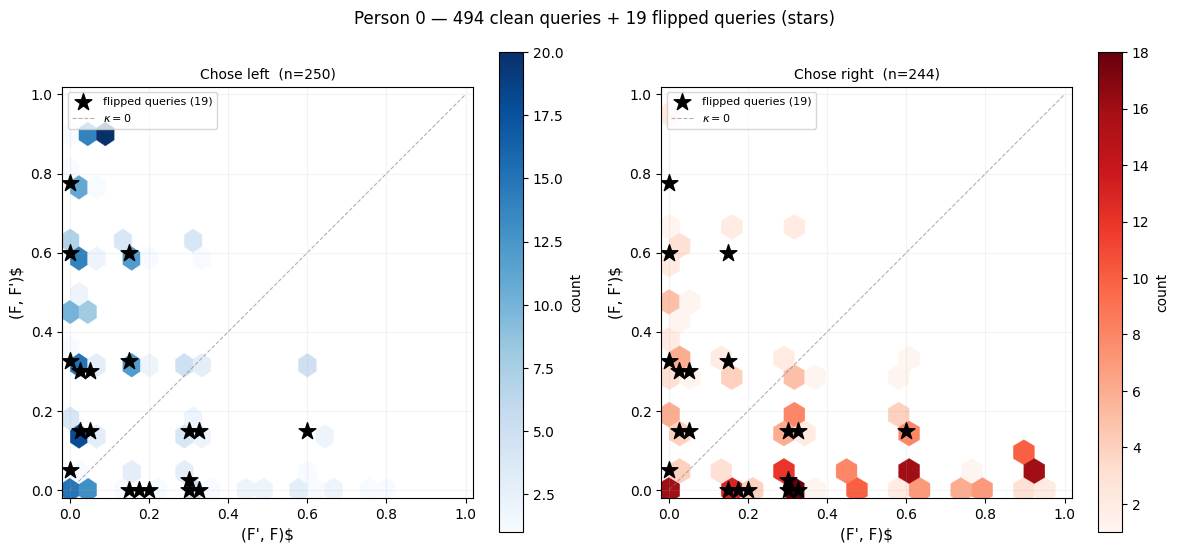

Saved clean_queries_density_flipped.png


In [7]:
# ── Density + flipped query stars ────────────────────────────────────────────
# Get one representative point per flipped query (first occurrence)
flipped_df = p0[flipped_mask].copy()
flip_unique = flipped_df.drop_duplicates(subset=DIFF_COLS)

c_flip = flip_unique[DIFF_COLS].values / RAW_MAX
d_flip = np.abs(c_flip)
r_flip  = d_flip  @ omega_best
k_flip  = c_flip  @ omega_best
sx_flip = (r_flip - k_flip) / 2
sy_flip = (r_flip + k_flip) / 2
print(f"Flipped queries: {len(flip_unique)} unique positions")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle("Person 0 — 494 clean queries + 19 flipped queries (stars)", fontsize=12)

gridsize = 18

for ax, mask, title, cmap in [
    (axes[0], left,  f"Chose left  (n={left.sum()})",  "Blues"),
    (axes[1], right, f"Chose right  (n={right.sum()})", "Reds"),
]:
    hb = ax.hexbin(sx_c[mask], sy_c[mask], gridsize=gridsize,
                   cmap=cmap, mincnt=1, linewidths=0.3)
    plt.colorbar(hb, ax=ax, label="count")
    # Overlay flipped queries as stars
    ax.scatter(sx_flip, sy_flip, marker="*", s=160, c="black",
               zorder=5, label=f"flipped queries ({len(sx_flip)})")
    ax.plot([0, 1], [0, 1], "gray", ls="--", lw=0.8, alpha=0.6, label=r"$\kappa=0$")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    ax.set_xlabel(r"(F', F)$", fontsize=11)
    ax.set_ylabel(r"(F, F')$", fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig("clean_queries_density_flipped.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved clean_queries_density_flipped.png")


Omega (min |kappa| on flipped):  [0.1 0.3 0.6 0. ]
Mean |kappa| on flipped queries: 0.1553

Omega (best soft-margin fit):     [0.3 0.  0.1 0.6]
Mean |kappa| on flipped queries: 0.2803


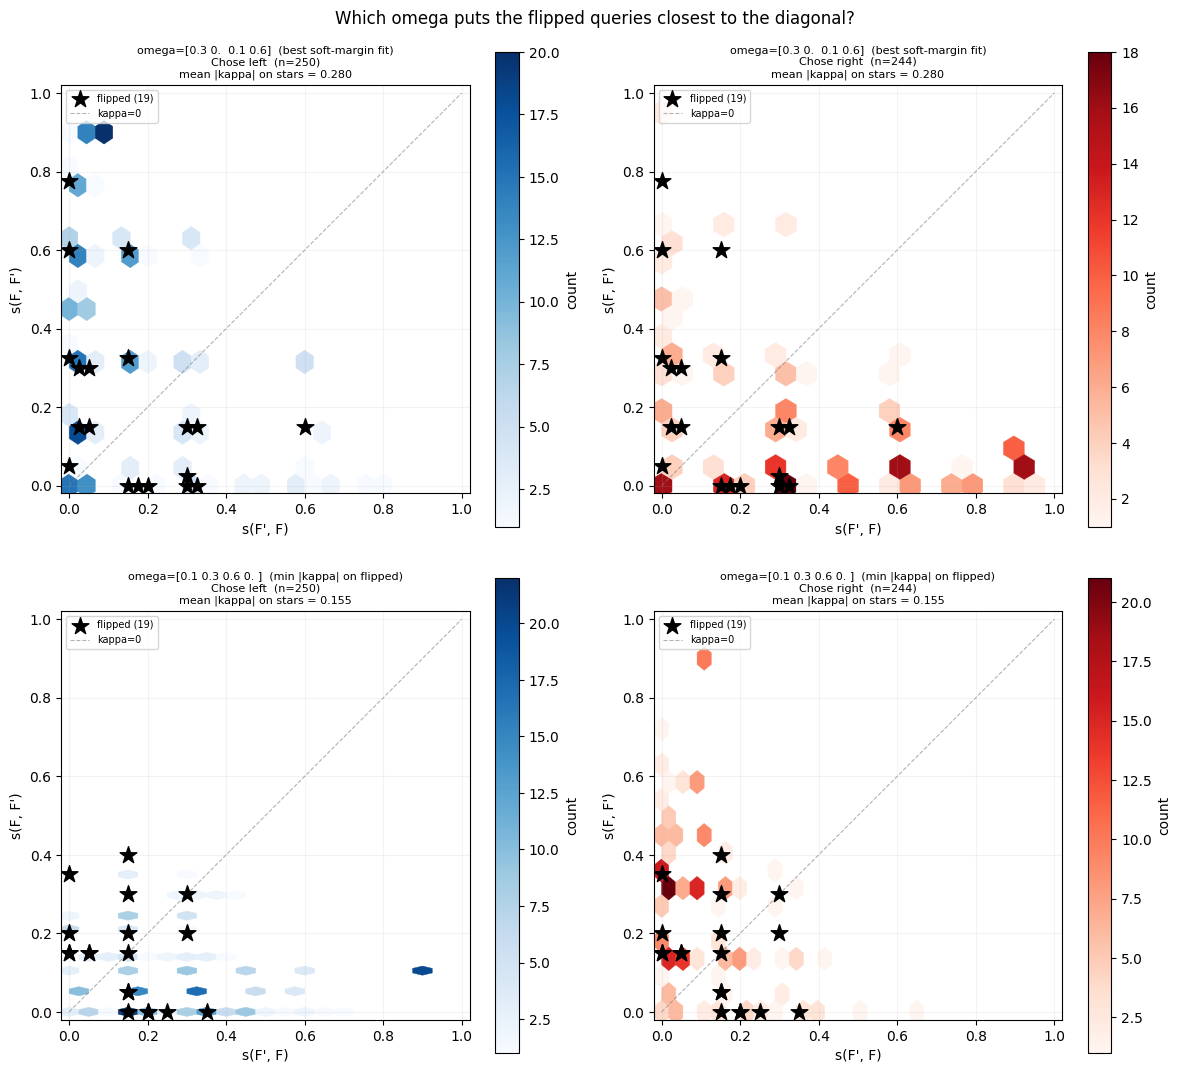

Saved omega_comparison.png


In [8]:
# ── Find omega that minimises mean |kappa| for the 19 flipped queries ─────────

c_flip_mat = flip_unique[DIFF_COLS].values / RAW_MAX
d_flip_mat = np.abs(c_flip_mat)

best_score_flip = np.inf
omega_flip = None
for omega in OMEGA_GRID:
    mean_abs_kappa = np.abs(c_flip_mat @ omega).mean()
    if mean_abs_kappa < best_score_flip:
        best_score_flip = mean_abs_kappa
        omega_flip = omega.copy()

print(f"Omega (min |kappa| on flipped):  {np.round(omega_flip, 2)}")
print(f"Mean |kappa| on flipped queries: {best_score_flip:.4f}")
print()
print(f"Omega (best soft-margin fit):     {np.round(omega_best, 2)}")
print(f"Mean |kappa| on flipped queries: {np.abs(c_flip_mat @ omega_best).mean():.4f}")

def make_density_panel(ax_left, ax_right, omega, title_prefix):
    r_  = d_clean @ omega
    k_  = c_clean @ omega
    sx_ = (r_ - k_) / 2
    sy_ = (r_ + k_) / 2
    r_f  = d_flip_mat @ omega
    k_f  = c_flip_mat @ omega
    sx_f = (r_f - k_f) / 2
    sy_f = (r_f + k_f) / 2
    mean_dist = np.abs(k_f).mean()
    for ax, mask, choice_title, cmap in [
        (ax_left,  left,  "Chose left  (n={})".format(left.sum()),  "Blues"),
        (ax_right, right, "Chose right  (n={})".format(right.sum()), "Reds"),
    ]:
        hb = ax.hexbin(sx_[mask], sy_[mask], gridsize=18, cmap=cmap, mincnt=1, linewidths=0.3)
        plt.colorbar(hb, ax=ax, label="count")
        ax.scatter(sx_f, sy_f, marker="*", s=160, c="black", zorder=5,
                   label="flipped ({})".format(len(sx_f)))
        ax.plot([0, 1], [0, 1], "gray", ls="--", lw=0.8, alpha=0.6, label="kappa=0")
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        ax.set_aspect("equal")
        ax.set_xlabel("s(F', F)", fontsize=10)
        ax.set_ylabel("s(F, F')", fontsize=10)
        ax.set_title("{}\n{}\nmean |kappa| on stars = {:.3f}".format(
            title_prefix, choice_title, mean_dist), fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.15)

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
fig.suptitle("Which omega puts the flipped queries closest to the diagonal?", fontsize=12)

make_density_panel(axes[0, 0], axes[0, 1], omega_best,
    "omega={}  (best soft-margin fit)".format(np.round(omega_best, 2)))
make_density_panel(axes[1, 0], axes[1, 1], omega_flip,
    "omega={}  (min |kappa| on flipped)".format(np.round(omega_flip, 2)))

plt.tight_layout()
plt.savefig("omega_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved omega_comparison.png")


Bradley-Terry (corrected signs)  —  600 trials, person 0
-------------------------------------------------------
  beta (raw):              [1.791 6.968 4.801 4.442]
  beta (simplex-projected): [0.1   0.387 0.267 0.247]
  log-likelihood:          -121.891
  accuracy:                0.912

  Soft-margin omega:       [0.3 0.  0.1 0.6]
  Min-kappa-flip omega:    [0.1 0.3 0.6 0. ]


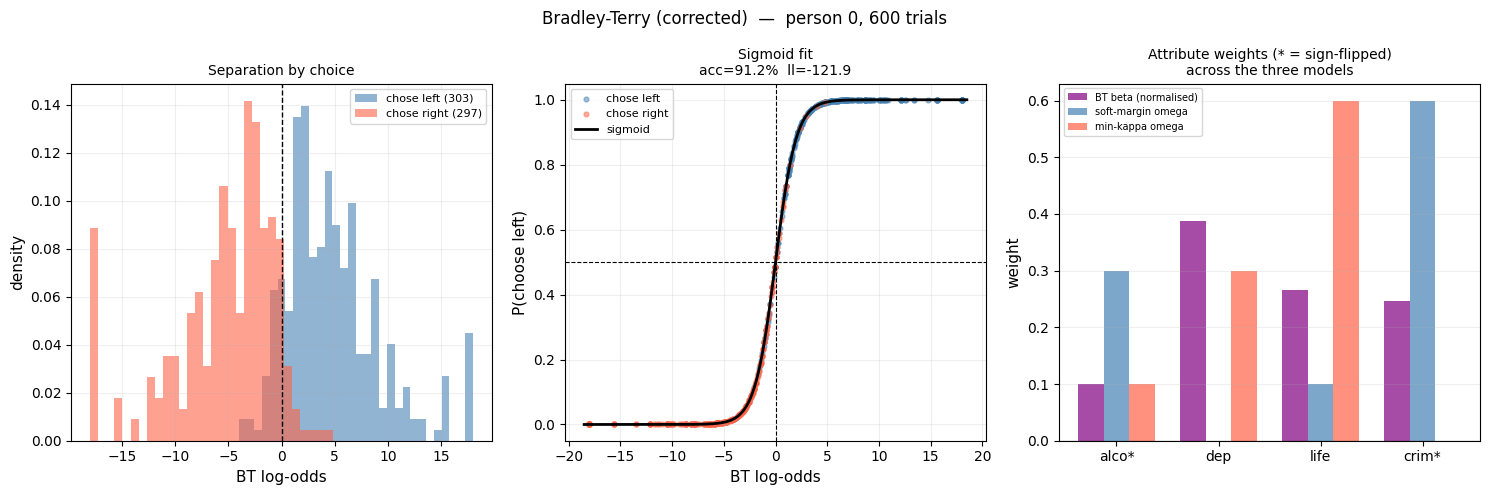

Saved bradley_terry_corrected.png


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# ── Bradley-Terry (corrected sign conventions) ───────────────────────────────
# Corrections applied:
#   1. choice 0 = left → y_bt = (chosen == 0)
#   2. alco and crim are 'lower = better', so negate their diffs so
#      higher transformed diff always means 'left is a better candidate'

SIGN = np.array([-1., 1., 1., -1.])   # [alco, dep, life, crim]
c_bt  = c_full * SIGN                  # flip alco and crim
y_bt  = (y_full == 0).astype(int)      # 1 = chose left

bt2 = LogisticRegression(fit_intercept=False, C=1e6, max_iter=1000)
bt2.fit(c_bt, y_bt)
beta2  = bt2.coef_[0]
probs2 = bt2.predict_proba(c_bt)[:, 1]
ll2    = -log_loss(y_bt, probs2, normalize=False)
acc2   = bt2.score(c_bt, y_bt)

# Project onto simplex: clip negatives then normalise
beta2_pos  = np.maximum(beta2, 0)
beta2_norm = beta2_pos / beta2_pos.sum() if beta2_pos.sum() > 0 else beta2_pos

print('Bradley-Terry (corrected signs)  —  600 trials, person 0')
print('-' * 55)
print(f'  beta (raw):              {np.round(beta2, 3)}')
print(f'  beta (simplex-projected): {np.round(beta2_norm, 3)}')
print(f'  log-likelihood:          {ll2:.3f}')
print(f'  accuracy:                {acc2:.3f}')
print()
print(f'  Soft-margin omega:       {np.round(omega_best, 2)}')
print(f'  Min-kappa-flip omega:    {np.round(omega_flip, 2)}')

logodds2 = c_bt @ beta2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Bradley-Terry (corrected)  —  person 0, 600 trials', fontsize=12)

# Panel 1: histogram separation
axes[0].hist(logodds2[y_bt==1], bins=30, alpha=0.6, color='steelblue',
             density=True, label='chose left ({})'.format((y_bt==1).sum()))
axes[0].hist(logodds2[y_bt==0], bins=30, alpha=0.6, color='tomato',
             density=True, label='chose right ({})'.format((y_bt==0).sum()))
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_xlabel('BT log-odds', fontsize=11)
axes[0].set_ylabel('density', fontsize=11)
axes[0].set_title('Separation by choice', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# Panel 2: sigmoid
xs = np.linspace(logodds2.min()-0.5, logodds2.max()+0.5, 300)
axes[1].scatter(logodds2[y_bt==1], probs2[y_bt==1], c='steelblue', s=12, alpha=0.5, label='chose left')
axes[1].scatter(logodds2[y_bt==0], probs2[y_bt==0], c='tomato',    s=12, alpha=0.5, label='chose right')
axes[1].plot(xs, 1/(1+np.exp(-xs)), 'k-', lw=2, label='sigmoid')
axes[1].axvline(0, color='black', lw=0.8, ls='--')
axes[1].axhline(0.5, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('BT log-odds', fontsize=11)
axes[1].set_ylabel('P(choose left)', fontsize=11)
axes[1].set_title('Sigmoid fit\nacc={:.1%}  ll={:.1f}'.format(acc2, ll2), fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

# Panel 3: weight comparison
attrs = ['alco*', 'dep', 'life', 'crim*']
x = np.arange(len(attrs))
w = 0.25
axes[2].bar(x - w, beta2 / np.abs(beta2).sum(), width=w,
            label='BT beta (normalised)', color='purple', alpha=0.7)
axes[2].bar(x,     omega_best, width=w,
            label='soft-margin omega',   color='steelblue', alpha=0.7)
axes[2].bar(x + w, omega_flip, width=w,
            label='min-kappa omega',     color='tomato', alpha=0.7)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(attrs, fontsize=10)
axes[2].set_ylabel('weight', fontsize=11)
axes[2].set_title('Attribute weights (* = sign-flipped)\nacross the three models', fontsize=10)
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('bradley_terry_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bradley_terry_corrected.png')


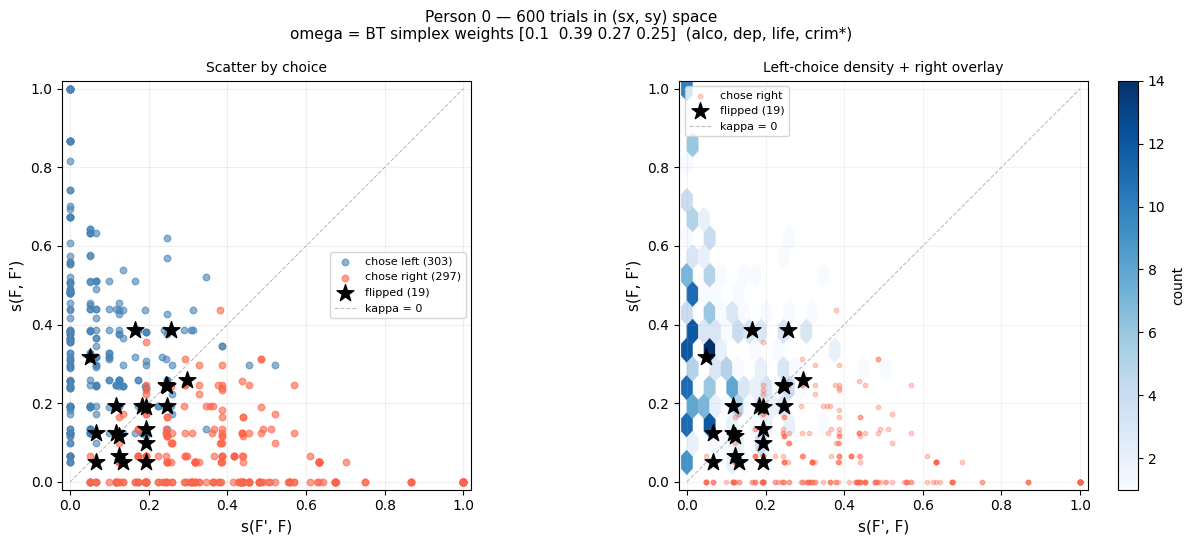

Saved bt_sx_sy.png
mean |kappa| on flipped queries: 0.0701


In [10]:
# ── (sx, sy) scatter using BT simplex-projected weights ─────────────────────
# Use beta2_norm as omega; c_bt already has alco/crim sign-flipped.
# d_bt = |c_bt| = d_full (absolute diffs, sign-flip doesn't change magnitude)

r_bt2  = d_full    @ beta2_norm   # decisiveness under BT weights
k_bt2  = c_bt      @ beta2_norm   # signed preference under BT weights
sx_bt2 = (r_bt2 - k_bt2) / 2
sy_bt2 = (r_bt2 + k_bt2) / 2

# Flipped queries position under BT weights
c_flip_bt  = c_flip_mat * SIGN
r_fbt  = d_flip_mat  @ beta2_norm
k_fbt  = c_flip_bt   @ beta2_norm
sx_fbt = (r_fbt - k_fbt) / 2
sy_fbt = (r_fbt + k_fbt) / 2

left_bt  = y_bt == 1   # chose left
right_bt = y_bt == 0   # chose right

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    'Person 0 — 600 trials in (sx, sy) space\n'
    'omega = BT simplex weights {}  (alco, dep, life, crim*)'.format(np.round(beta2_norm, 2)),
    fontsize=11)

# Left panel: scatter by choice
axes[0].scatter(sx_bt2[left_bt],  sy_bt2[left_bt],  c='steelblue', s=22, alpha=0.6,
                label='chose left ({})'.format(left_bt.sum()))
axes[0].scatter(sx_bt2[right_bt], sy_bt2[right_bt], c='tomato',    s=22, alpha=0.6,
                label='chose right ({})'.format(right_bt.sum()))
axes[0].scatter(sx_fbt, sy_fbt, marker='*', s=160, c='black', zorder=5,
                label='flipped ({})'.format(len(sx_fbt)))
axes[0].plot([0, 1], [0, 1], 'gray', ls='--', lw=0.8, alpha=0.5, label='kappa = 0')
axes[0].set_xlim(-0.02, 1.02); axes[0].set_ylim(-0.02, 1.02)
axes[0].set_aspect('equal')
axes[0].set_xlabel("s(F', F)", fontsize=11)
axes[0].set_ylabel("s(F, F')", fontsize=11)
axes[0].set_title('Scatter by choice', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

# Right panel: density (hexbin) left only — reuse existing style
hb = axes[1].hexbin(sx_bt2[left_bt], sy_bt2[left_bt], gridsize=18,
                    cmap='Blues', mincnt=1, linewidths=0.3)
plt.colorbar(hb, ax=axes[1], label='count')
axes[1].scatter(sx_bt2[right_bt], sy_bt2[right_bt], c='tomato', s=10, alpha=0.3,
                label='chose right')
axes[1].scatter(sx_fbt, sy_fbt, marker='*', s=160, c='black', zorder=5,
                label='flipped ({})'.format(len(sx_fbt)))
axes[1].plot([0, 1], [0, 1], 'gray', ls='--', lw=0.8, alpha=0.5, label='kappa = 0')
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)
axes[1].set_aspect('equal')
axes[1].set_xlabel("s(F', F)", fontsize=11)
axes[1].set_ylabel("s(F, F')", fontsize=11)
axes[1].set_title('Left-choice density + right overlay', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('bt_sx_sy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bt_sx_sy.png')
print(f'mean |kappa| on flipped queries: {np.abs(k_fbt).mean():.4f}')
